# SRQ2 — NCA + kNN Pipeline Evaluation

Replaces the trained linear classifier head with a post-hoc NCA + kNN pipeline applied to 512-dimensional backbone embeddings. Evaluates whether metric-space classification improves over the linear head baseline, and whether the benefit differs across backbone architectures.

**Backbones evaluated (3 total):**
- `base` — plain ResNet18 (contextual baseline)
- `cbam_end` — best SRQ1 architecture
- `se_block_pre` — SRQ1 runner-up (cross-backbone comparison)

**Protocol:**
- **Parameter selection:** `target_dim` ∈ {64, 128, 256, 512} and `k` ∈ {1, 3, 5, 7, 9} selected independently per backbone via 3-fold CV in feature space. Each backbone's feature space may respond differently to NCA compression, so per-backbone selection ensures each is evaluated under its optimal pipeline configuration. Cross-backbone comparisons are made on Δ gain (NCA+kNN F1 − linear F1) rather than absolute scores.
- **Evaluation:** For each backbone, each of the 5 saved fold weights is loaded, 512-dim embeddings extracted, and NCA+kNN applied with that backbone's selected parameters. - Results saved fold-by-fold to `nca-knn-results/nca_knn_results.csv` — safe to interrupt and resume.
- All plots saved as both `.png` (raster) and `.svg` (vector) for dissertation use.

## 1 · Paths & Imports

In [1]:
import sys
from pathlib import Path

ABSOLUTE_PATH = Path().resolve()
PROJECT_ROOT  = ABSOLUTE_PATH.parents[2]
DATA_DIR      = PROJECT_ROOT / "data" / "raw"
ARCH_EVAL_DIR = ABSOLUTE_PATH / "arch-eval-results"
RESULTS_DIR   = ABSOLUTE_PATH / "nca-knn-results"
WEIGHTS_DIR   = ARCH_EVAL_DIR / "weights"
PLOTS_DIR     = RESULTS_DIR / "plots"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

sys.path.append(str(PROJECT_ROOT))

print(f"Project root  : {PROJECT_ROOT}")
print(f"Data dir      : {DATA_DIR}")
print(f"Arch-eval dir : {ARCH_EVAL_DIR}")
print(f"Results dir   : {RESULTS_DIR}")
print(f"Plots dir     : {PLOTS_DIR}")
print(f"Weights dir   : {WEIGHTS_DIR}")

Project root  : C:\Users\markm\Workspace\ms-machine-learning-diagnosis
Data dir      : C:\Users\markm\Workspace\ms-machine-learning-diagnosis\data\raw
Arch-eval dir : C:\Users\markm\Workspace\ms-machine-learning-diagnosis\src\notebooks\CNNS\arch-eval-results
Results dir   : C:\Users\markm\Workspace\ms-machine-learning-diagnosis\src\notebooks\CNNS\nca-knn-results
Plots dir     : C:\Users\markm\Workspace\ms-machine-learning-diagnosis\src\notebooks\CNNS\nca-knn-results\plots
Weights dir   : C:\Users\markm\Workspace\ms-machine-learning-diagnosis\src\notebooks\CNNS\arch-eval-results\weights


In [2]:
import csv
import itertools
import traceback
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.metrics import f1_score
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler

import src.scripts.data      as data
import src.scripts.models    as models
import src.scripts.trainer   as trainer
import src.scripts.evaluator as evaluator
import src.scripts.utils     as utils

utils.set_seed(42)

Random seed set to 42 for Python, NumPy, and PyTorch


## 2 · Data — Identical Outer Split

Same seed-42 outer split as all other experiments. The held-out test set is set aside and not used until Section 8 (final evaluation).

In [3]:
path, categories = data.get_dataset(str(DATA_DIR))
classes = data.get_classes(path, categories, visualise=False)

image_paths, labels = data.get_paths_and_labels(path, classes)
train_transform, test_transform = data.get_transforms()

X_trainval, y_trainval, X_test, y_test = data.get_trainval_test_split(
    image_paths, labels,
    test_split=0.20,
    SEED=42
)

print(f"\nNCA+kNN evaluation operates on {len(X_trainval)} train+val samples.")
print("Held-out test set is NOT used until Section 8.")

get_dataset()>>> Dataset already exists in C:\Users\markm\Workspace\ms-machine-learning-diagnosis\data\raw
get_dataset()>>> Available categories: ['Control Axial_crop', 'Control Saggital_crop', 'MS Axial_crop', 'MS Saggital_crop']
get_paths_and_labels()>>> Total images: 1652
get_trainval_test_split()>>> Train+Val pool : 1321 (80.0%)
get_trainval_test_split()>>> Held-out test  : 331 (20.0%)
get_trainval_test_split()>>> TrainVal class ratio — MS: 520  Non-MS: 801
get_trainval_test_split()>>> Test     class ratio — MS: 130  Non-MS: 201

NCA+kNN evaluation operates on 1321 train+val samples.
Held-out test set is NOT used until Section 8.


## 3 · Configuration

In [4]:
# ── Load arch-eval results for linear head baseline ──────────────────────────
ARCH_RESULTS_FILE = ARCH_EVAL_DIR / "arch_eval_results.csv"
if not ARCH_RESULTS_FILE.exists():
    raise FileNotFoundError(
        f"arch_eval_results.csv not found at {ARCH_RESULTS_FILE}\n"
        "Run the architecture evaluation notebook first."
    )

df_arch = pd.read_csv(ARCH_RESULTS_FILE)
df_arch["error"] = df_arch["error"].fillna("")
df_arch_ok = df_arch[df_arch["error"] == ""].copy()

linear_baseline = (
    df_arch_ok.groupby("architecture")["val_f1"]
    .agg(["mean", "std"])
    .rename(columns={"mean": "linear_f1_mean", "std": "linear_f1_std"})
)
print("Linear head baselines (from arch-eval):\n")
print(linear_baseline.to_string())

Linear head baselines (from arch-eval):

                         linear_f1_mean  linear_f1_std
architecture                                          
base                           0.917381       0.027247
cbam_block_post                0.899055       0.029739
cbam_block_pre                 0.863452       0.057110
cbam_end                       0.925361       0.022225
cbam_isolated_block_pre        0.891668       0.033113
cbam_isolated_end              0.905087       0.033265
se_block_pre                   0.906957       0.030946
se_end                         0.904073       0.041417


In [5]:
# ── Load winning head ────────────────────────────────────────────────────────
OPTIMAL_HEAD_FILE = ABSOLUTE_PATH / "head-ablation-results" / "optimal_head.csv"
if not OPTIMAL_HEAD_FILE.exists():
    raise FileNotFoundError(
        f"optimal_head.csv not found at {OPTIMAL_HEAD_FILE}\n"
        "Run the head ablation notebook first."
    )
optimal_head = pd.read_csv(OPTIMAL_HEAD_FILE).iloc[0]
WINNING_HEAD = optimal_head["head"]
print(f"Winning head : {WINNING_HEAD}")

Winning head : linear


In [6]:
# ── Backbones and search grid ─────────────────────────────────────────────────
BACKBONES = ["base", "cbam_end", "se_block_pre"]

N_SPLITS_EVAL   = 5    # matches arch-eval; reuses saved fold weights
N_SPLITS_SEARCH = 3    # inner CV folds for per-backbone parameter selection
SEED            = 42
BATCH_SIZE      = 32

TARGET_DIMS = [64, 128, 256, 512]
KS          = [1, 3, 5, 7, 9]

# ── Output ────────────────────────────────────────────────────────────────────
RESULTS_FILE      = RESULTS_DIR / "nca_knn_results.csv"
OPT_PARAMS_FILE   = RESULTS_DIR / "optimal_params.csv"
CSV_FIELDNAMES = [
    "backbone", "target_dim", "k",
    "fold", "nca_knn_f1", "linear_f1", "delta_f1",
    "timestamp", "error"
]
OPT_FIELDNAMES = ["backbone", "target_dim", "k", "mean_f1", "std_f1"]

print(f"Backbones      : {BACKBONES}")
print(f"Target dims    : {TARGET_DIMS}")
print(f"k values       : {KS}")
print(f"Eval folds     : {N_SPLITS_EVAL}")
print(f"Search folds   : {N_SPLITS_SEARCH}")
print(f"Results        → {RESULTS_FILE}")
print(f"Optimal params → {OPT_PARAMS_FILE}")

Backbones      : ['base', 'cbam_end', 'se_block_pre']
Target dims    : [64, 128, 256, 512]
k values       : [1, 3, 5, 7, 9]
Eval folds     : 5
Search folds   : 3
Results        → C:\Users\markm\Workspace\ms-machine-learning-diagnosis\src\notebooks\CNNS\nca-knn-results\nca_knn_results.csv
Optimal params → C:\Users\markm\Workspace\ms-machine-learning-diagnosis\src\notebooks\CNNS\nca-knn-results\optimal_params.csv


## 4 · Helpers

In [7]:
def save_fig(fig, stem):
    """Save figure as both PNG and SVG to PLOTS_DIR."""
    for ext in ("png", "svg"):
        out = PLOTS_DIR / f"{stem}.{ext}"
        fig.savefig(out, dpi=150, bbox_inches="tight",
                    format=ext,
                    # SVG: embed fonts as paths so the file is self-contained
                    metadata={"Creator": "matplotlib"} if ext == "svg" else {})
    print(f"Saved → {PLOTS_DIR / stem}.png / .svg")


def load_completed_runs(results_file):
    """Return set of (backbone, fold) tuples already written without error."""
    completed = set()
    if results_file.exists():
        with open(results_file, newline="") as f:
            reader = csv.DictReader(f)
            for row in reader:
                if row["error"] == "":
                    completed.add((row["backbone"], int(row["fold"])))
    return completed


def append_result(results_file, fieldnames, row_dict):
    """Append one result row to CSV, writing header if the file is new."""
    write_header = not results_file.exists()
    with open(results_file, "a", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        if write_header:
            writer.writeheader()
        writer.writerow(row_dict)


def fold_weights_path(backbone, fold_idx):
    """Return path to arch-eval saved weights for a given backbone and fold."""
    p = WEIGHTS_DIR / backbone / f"fold_{fold_idx}.pt"
    if not p.exists():
        raise FileNotFoundError(
            f"Weights not found: {p}\n"
            "Ensure the architecture evaluation notebook has completed all folds."
        )
    return p


def extract_features(backbone_name, fold_idx, train_loader, val_loader, device):
    """Load saved fold weights and extract 512-dim avgpool embeddings."""
    model = models.get_model(architecture=backbone_name, head=WINNING_HEAD)
    model = utils.load_weights(model, fold_weights_path(backbone_name, fold_idx), device=device)
    model.eval()
    X_train, y_train = trainer.get_features(model, train_loader, device=device)
    X_val,   y_val   = trainer.get_features(model, val_loader,   device=device)
    return X_train, y_train, X_val, y_val


def run_nca_knn_scored(X_train_raw, y_train, X_val_raw, y_val, target_dim, k):
    """
    StandardScaler → NCA(target_dim) → kNN(k, distance-weighted).
    Scaler and NCA fit on training data only — no leakage.
    Returns val F1.
    """
    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_train_raw)
    X_va = scaler.transform(X_val_raw)

    X_tr_nca, X_va_nca = trainer.get_nca_features(
        X_tr, y_train, X_va,
        TARGET_DIM=target_dim, SEED=SEED
    )

    knn = trainer.get_and_train_knn(X_tr_nca, y_train, NUM_NEIGHBOURS=k)
    y_pred = evaluator.predict_knn(knn, X_va_nca)
    return f1_score(y_val, y_pred, average="binary", zero_division=0)


def load_optimal_params():
    """Load saved per-backbone optimal parameters if they exist."""
    if OPT_PARAMS_FILE.exists():
        df = pd.read_csv(OPT_PARAMS_FILE)
        return {row["backbone"]: (int(row["target_dim"]), int(row["k"]))
                for _, row in df.iterrows()}
    return {}

## 5 · Per-Backbone Parameter Selection

Grid search over `target_dim` × `k` using 3-fold CV in feature space, run independently for each backbone. Features are extracted once per backbone (using fold-0 weights as representative) then the CV search operates entirely in numpy — no CNN retraining per grid point.

**Why per-backbone?** Each backbone's feature space has different intrinsic dimensionality and cluster structure. Parameters optimal for `base` embeddings may not be optimal for attention-augmented spaces. Per-backbone selection ensures each architecture is evaluated under its own best pipeline configuration.

**Why fold-0 for feature extraction?** Fold-0 weights were trained on ~80% of `X_trainval`, the same proportion as all other folds. Using any single fold as representative is consistent with standard practice for post-hoc parameter selection.

Results are saved to `optimal_params.csv` — rerunning this section is safe and will skip backbones already completed.

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}\n")

# Load any previously saved optimal params (resume support)
optimal_params = load_optimal_params()
all_search_results = {}   # backbone → DataFrame

for backbone in BACKBONES:

    if backbone in optimal_params:
        td, k = optimal_params[backbone]
        print(f"SKIP  {backbone} — already selected: target_dim={td}  k={k}")
        continue

    print(f"\n{'='*65}")
    print(f"  Parameter search — backbone: {backbone}")
    print(f"{'='*65}")

    # ── Extract features from full X_trainval using fold-0 weights ────────────
    print(f"  Loading {backbone} fold-0 weights...")
    model = models.get_model(architecture=backbone, head=WINNING_HEAD)
    model = utils.load_weights(model, fold_weights_path(backbone, 0), device=device)
    model.eval()

    all_loader = data.get_test_loader(
        X_trainval, y_trainval, test_transform, batch_size=BATCH_SIZE
    )
    print(f"  Extracting features from {len(X_trainval)} samples...")
    X_all, y_all = trainer.get_features(model, all_loader, device=device)
    print(f"  Feature matrix shape: {X_all.shape}")

    # ── 3-fold CV grid search in feature space ────────────────────────────────
    total_fits = len(TARGET_DIMS) * len(KS) * N_SPLITS_SEARCH
    print(f"  Grid: {len(TARGET_DIMS)} dims × {len(KS)} k values × {N_SPLITS_SEARCH} folds = {total_fits} NCA fits")

    search_rows = []
    skf = StratifiedKFold(n_splits=N_SPLITS_SEARCH, shuffle=True, random_state=SEED)
    X_arr, y_arr = np.array(X_all), np.array(y_all)

    for target_dim, k in itertools.product(TARGET_DIMS, KS):
        fold_f1s = []
        for tr_idx, va_idx in skf.split(X_arr, y_arr):
            try:
                f1 = run_nca_knn_scored(
                    X_arr[tr_idx], y_arr[tr_idx],
                    X_arr[va_idx], y_arr[va_idx],
                    target_dim, k
                )
                fold_f1s.append(f1)
            except Exception as e:
                print(f"    WARN target_dim={target_dim} k={k}: {e}")
                fold_f1s.append(0.0)

        mean_f1 = float(np.mean(fold_f1s))
        std_f1  = float(np.std(fold_f1s))
        search_rows.append({"target_dim": target_dim, "k": k,
                             "mean_f1": mean_f1, "std_f1": std_f1})
        print(f"    dim={target_dim:3d}  k={k}  F1={mean_f1:.4f} ± {std_f1:.4f}")

    df_search = (
        pd.DataFrame(search_rows)
        .sort_values(["mean_f1", "target_dim"], ascending=[False, True])
    )
    all_search_results[backbone] = df_search

    best = df_search.iloc[0]
    OPT_TD = int(best["target_dim"])
    OPT_K  = int(best["k"])
    optimal_params[backbone] = (OPT_TD, OPT_K)

    print(f"\n  Selected: target_dim={OPT_TD}  k={OPT_K}  "          f"mean_F1={best['mean_f1']:.4f} ± {best['std_f1']:.4f}")

    # Append to optimal_params.csv
    append_result(
        OPT_PARAMS_FILE, OPT_FIELDNAMES,
        {"backbone": backbone, "target_dim": OPT_TD, "k": OPT_K,
         "mean_f1": round(best["mean_f1"], 6), "std_f1": round(best["std_f1"], 6)}
    )

print(f"\n{'='*65}")
print("PARAMETER SELECTION COMPLETE")
print(f"Optimal params saved to: {OPT_PARAMS_FILE}")
print()
for b, (td, k) in optimal_params.items():
    print(f"  {b:<30} target_dim={td}  k={k}")

Device: cpu


  Parameter search — backbone: base
  Loading base fold-0 weights...
get_model()>>> architecture='base'  head='linear'
load_weights()>>> Model loaded successfully and set to evaluation mode.
get_test_loader()>>> Test loader ready — 1321 samples
  Extracting features from 1321 samples...
  Feature matrix shape: (1321, 512)
  Grid: 4 dims × 5 k values × 3 folds = 60 NCA fits
get_nca_features()>>> Fitting NCA to reduce 512 features to 64...
get_nca_features()>>> Reduced Train Feature Shape: (880, 64)
get_nca_features()>>> Reduced Test Feature Shape: (441, 64)
get_and_train_knn()>>> Training kNN classifier on NCA selected deep features...
predict_knn()>>> Predicting test set labels using kNN classifier...
get_nca_features()>>> Fitting NCA to reduce 512 features to 64...
get_nca_features()>>> Reduced Train Feature Shape: (881, 64)
get_nca_features()>>> Reduced Test Feature Shape: (440, 64)
get_and_train_knn()>>> Training kNN classifier on NCA selected deep features...
predict_

### 5.1 · Parameter Search Heatmaps

One heatmap per backbone. The selected `(target_dim, k)` is outlined in orange.

Saved → C:\Users\markm\Workspace\ms-machine-learning-diagnosis\src\notebooks\CNNS\nca-knn-results\plots\param_search_heatmaps.png / .svg


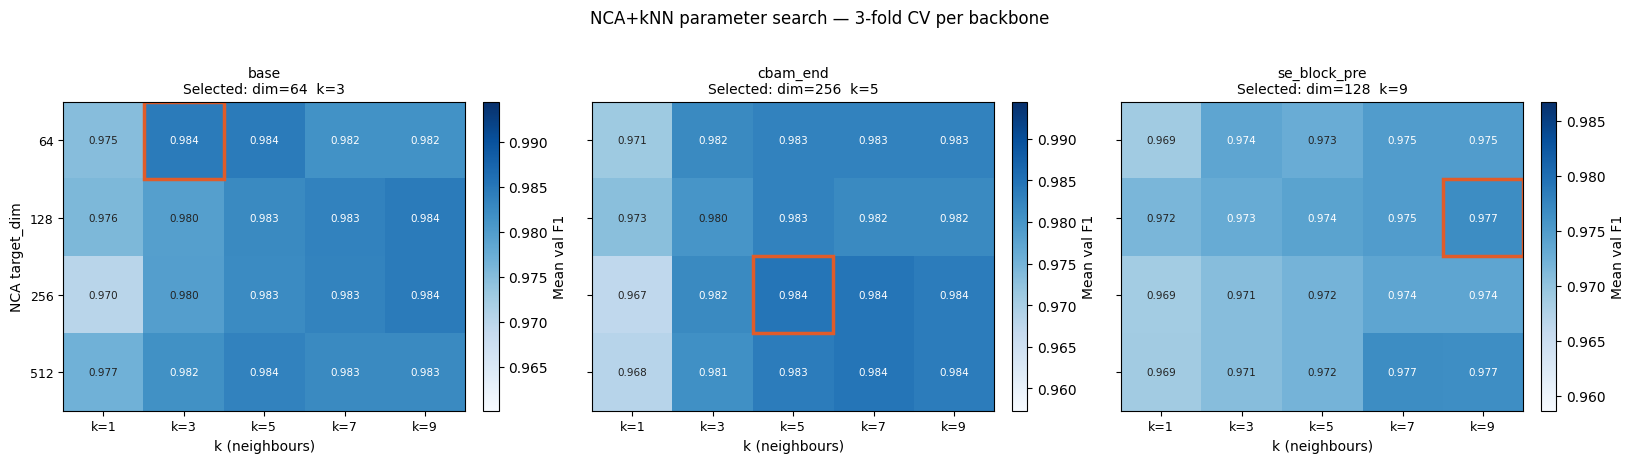

In [9]:
# Load search results for any backbones completed in a previous run
if not all_search_results:
    search_csv = RESULTS_DIR / "param_search_results.csv"
    if search_csv.exists():
        df_s = pd.read_csv(search_csv)
        for backbone in BACKBONES:
            sub = df_s[df_s["backbone"] == backbone]
            if not sub.empty:
                all_search_results[backbone] = sub[["target_dim", "k", "mean_f1", "std_f1"]]

if not all_search_results:
    print("No search results yet — run Section 5 first.")
else:
    fig, axes = plt.subplots(1, len(BACKBONES),
                              figsize=(5.5 * len(BACKBONES), 4.5),
                              sharey=True)
    if len(BACKBONES) == 1:
        axes = [axes]

    for ax, backbone in zip(axes, BACKBONES):
        df_b = all_search_results.get(backbone)
        if df_b is None:
            ax.set_title(f"{backbone}\n(not yet run)")
            continue

        pivot = df_b.pivot(index="target_dim", columns="k", values="mean_f1")
        im = ax.imshow(pivot.values, aspect="auto", cmap="Blues",
                       vmin=pivot.values.min() - 0.01,
                       vmax=pivot.values.max() + 0.01)

        ax.set_xticks(range(len(pivot.columns)))
        ax.set_xticklabels([f"k={k}" for k in pivot.columns], fontsize=9)
        ax.set_yticks(range(len(pivot.index)))
        ax.set_yticklabels([f"{d}" for d in pivot.index], fontsize=9)
        ax.set_xlabel("k (neighbours)", fontsize=10)
        if ax == axes[0]:
            ax.set_ylabel("NCA target_dim", fontsize=10)

        td_opt, k_opt = optimal_params.get(backbone, (None, None))
        for i in range(len(pivot.index)):
            for j in range(len(pivot.columns)):
                val = pivot.values[i, j]
                ax.text(j, i, f"{val:.3f}", ha="center", va="center",
                        fontsize=7.5,
                        color="white" if val > pivot.values.mean() else "#222")

        if td_opt is not None and k_opt is not None:
            sel_row = list(pivot.index).index(td_opt)
            sel_col = list(pivot.columns).index(k_opt)
            ax.add_patch(plt.Rectangle(
                (sel_col - 0.5, sel_row - 0.5), 1, 1,
                fill=False, edgecolor="#E05C2A", linewidth=2.5
            ))
            title_suffix = f"\nSelected: dim={td_opt}  k={k_opt}"
        else:
            title_suffix = ""

        ax.set_title(f"{backbone}{title_suffix}", fontsize=10)
        plt.colorbar(im, ax=ax, label="Mean val F1", fraction=0.046, pad=0.04)

    plt.suptitle(
        f"NCA+kNN parameter search — 3-fold CV per backbone",
        fontsize=12, y=1.02
    )
    plt.tight_layout()
    save_fig(fig, "param_search_heatmaps")
    plt.show()

In [10]:
# Also save the full search table for the dissertation appendix
if all_search_results:
    dfs = []
    for backbone, df_b in all_search_results.items():
        df_copy = df_b.copy()
        df_copy.insert(0, "backbone", backbone)
        dfs.append(df_copy)
    search_all = pd.concat(dfs, ignore_index=True)
    search_path = RESULTS_DIR / "param_search_results.csv"
    search_all.to_csv(search_path, index=False)
    print(f"Full search table saved to: {search_path}")

Full search table saved to: C:\Users\markm\Workspace\ms-machine-learning-diagnosis\src\notebooks\CNNS\nca-knn-results\param_search_results.csv


## 6 · NCA + kNN Evaluation — All Three Backbones

For each backbone × fold: load saved arch-eval weights, extract 512-dim embeddings from that fold's train/val split, apply the pipeline with that backbone's own selected `(target_dim, k)`, compute val F1 and Δ against the linear head baseline.

Results written fold-by-fold — safe to interrupt and resume.

In [11]:
# Verify all optimal params are available before starting
missing_params = [b for b in BACKBONES if b not in optimal_params]
if missing_params:
    raise RuntimeError(
        f"Missing optimal params for: {missing_params}\n"
        "Run Section 5 first to complete parameter selection for all backbones."
    )

completed_runs = load_completed_runs(RESULTS_FILE)
run_number     = len(completed_runs)
total_runs     = len(BACKBONES) * N_SPLITS_EVAL

print(f"{len(BACKBONES)} backbones × {N_SPLITS_EVAL} folds = {total_runs} runs")
print(f"Already completed : {len(completed_runs)}")
print()
for b in BACKBONES:
    td, k = optimal_params[b]
    print(f"  {b:<30} target_dim={td}  k={k}")
print(f"\nResults → {RESULTS_FILE}\n")

for backbone in BACKBONES:
    td_opt, k_opt = optimal_params[backbone]

    for fold_idx in range(N_SPLITS_EVAL):

        run_key = (backbone, fold_idx)
        if run_key in completed_runs:
            print(f"SKIP  backbone={backbone}  fold={fold_idx+1}/{N_SPLITS_EVAL}")
            continue

        utils.set_seed(SEED)
        run_number += 1
        print(f"\n{'='*65}")
        print(f"  Run {run_number}/{total_runs}  |  backbone={backbone}  "              f"fold={fold_idx+1}/{N_SPLITS_EVAL}  "              f"[dim={td_opt}  k={k_opt}]")
        print(f"{'='*65}")

        try:
            train_loader, val_loader = data.get_fold_loaders(
                X_trainval, y_trainval,
                fold_idx=fold_idx,
                train_transform=train_transform,
                test_transform=test_transform,
                n_splits=N_SPLITS_EVAL,
                batch_size=BATCH_SIZE,
                SEED=SEED
            )

            X_train_raw, y_train_feat, X_val_raw, y_val_feat = extract_features(
                backbone, fold_idx, train_loader, val_loader, device
            )
            print(f"  Train: {X_train_raw.shape}   Val: {X_val_raw.shape}")

            nca_knn_f1 = run_nca_knn_scored(
                X_train_raw, y_train_feat,
                X_val_raw,   y_val_feat,
                target_dim=td_opt, k=k_opt
            )

            arch_fold_rows = df_arch_ok[
                (df_arch_ok["architecture"] == backbone) &
                (df_arch_ok["fold"] == fold_idx)
            ]
            linear_f1 = float(arch_fold_rows["val_f1"].iloc[0])                         if len(arch_fold_rows) else float("nan")
            delta_f1  = nca_knn_f1 - linear_f1                         if not np.isnan(linear_f1) else float("nan")

            row = {
                "backbone"  : backbone,
                "target_dim": td_opt,
                "k"         : k_opt,
                "fold"      : fold_idx,
                "nca_knn_f1": round(nca_knn_f1, 6),
                "linear_f1" : round(linear_f1,  6),
                "delta_f1"  : round(delta_f1,   6),
                "timestamp" : datetime.now().isoformat(timespec="seconds"),
                "error"     : "",
            }
            append_result(RESULTS_FILE, CSV_FIELDNAMES, row)
            completed_runs.add(run_key)

            print(f"  nca_knn_f1={nca_knn_f1:.4f}  "                  f"linear_f1={linear_f1:.4f}  Δ={delta_f1:+.4f}")

        except Exception as e:
            error_msg = f"{type(e).__name__}: {str(e)}"
            print(f"ERROR -- {error_msg}")
            traceback.print_exc()
            error_row = {
                "backbone": backbone, "target_dim": td_opt, "k": k_opt,
                "fold": fold_idx, "nca_knn_f1": "", "linear_f1": "",
                "delta_f1": "",
                "timestamp": datetime.now().isoformat(timespec="seconds"),
                "error": error_msg,
            }
            append_result(RESULTS_FILE, CSV_FIELDNAMES, error_row)

print(f"\n{'='*65}")
print("NCA+kNN EVALUATION COMPLETE")
print(f"Results → {RESULTS_FILE}")

3 backbones × 5 folds = 15 runs
Already completed : 0

  base                           target_dim=64  k=3
  cbam_end                       target_dim=256  k=5
  se_block_pre                   target_dim=128  k=9

Results → C:\Users\markm\Workspace\ms-machine-learning-diagnosis\src\notebooks\CNNS\nca-knn-results\nca_knn_results.csv

Random seed set to 42 for Python, NumPy, and PyTorch

  Run 1/15  |  backbone=base  fold=1/5  [dim=64  k=3]
get_fold_loaders()>>> Fold 1/5 — Train: 1056,  Val: 265
get_model()>>> architecture='base'  head='linear'
load_weights()>>> Model loaded successfully and set to evaluation mode.
  Train: (1056, 512)   Val: (265, 512)
get_nca_features()>>> Fitting NCA to reduce 512 features to 64...
get_nca_features()>>> Reduced Train Feature Shape: (1056, 64)
get_nca_features()>>> Reduced Test Feature Shape: (265, 64)
get_and_train_knn()>>> Training kNN classifier on NCA selected deep features...
predict_knn()>>> Predicting test set labels using kNN classifier...
  nc

## 7 · Results Analysis

Run after Section 6 completes (or at any point for partial results).

In [12]:
df_raw = pd.read_csv(RESULTS_FILE)
df_raw["error"] = df_raw["error"].fillna("")
df_ok   = df_raw[df_raw["error"] == ""].copy()
df_fail = df_raw[df_raw["error"] != ""].copy()

for col in ["nca_knn_f1", "linear_f1", "delta_f1"]:
    df_ok[col] = df_ok[col].astype(float)

print(f"Successful runs : {len(df_ok)} / {total_runs}")
print(f"Failed runs     : {len(df_fail)}")
if len(df_fail) > 0:
    print(df_fail[["backbone", "fold", "error"]].to_string(index=False))

Successful runs : 15 / 15
Failed runs     : 0


In [13]:
# ── Summary table ─────────────────────────────────────────────────────────────
summary = (
    df_ok.groupby("backbone")
    .agg(
        nca_knn_f1_mean = ("nca_knn_f1", "mean"),
        nca_knn_f1_std  = ("nca_knn_f1", "std"),
        linear_f1_mean  = ("linear_f1",  "mean"),
        linear_f1_std   = ("linear_f1",  "std"),
        delta_f1_mean   = ("delta_f1",   "mean"),
        delta_f1_std    = ("delta_f1",   "std"),
        n_folds         = ("nca_knn_f1", "count"),
    )
    .reset_index()
)

backbone_order = {b: i for i, b in enumerate(BACKBONES)}
summary["_order"] = summary["backbone"].map(backbone_order)
summary = summary.sort_values("_order").drop(columns="_order")

# Attach selected params
summary["target_dim"] = summary["backbone"].map(
    lambda b: optimal_params.get(b, (None, None))[0])
summary["k"] = summary["backbone"].map(
    lambda b: optimal_params.get(b, (None, None))[1])

summary["NCA+kNN F1"] = summary.apply(
    lambda r: f"{r.nca_knn_f1_mean:.4f} ± {r.nca_knn_f1_std:.4f}", axis=1)
summary["Linear F1"]  = summary.apply(
    lambda r: f"{r.linear_f1_mean:.4f} ± {r.linear_f1_std:.4f}",  axis=1)
summary["Δ F1"]        = summary.apply(
    lambda r: f"{r.delta_f1_mean:+.4f} ± {r.delta_f1_std:.4f}",   axis=1)

print("NCA+kNN vs linear head — summary (5-fold CV):\n")
print(summary[["backbone", "target_dim", "k",
               "Linear F1", "NCA+kNN F1", "Δ F1", "n_folds"]].to_string(index=False))

summary_path = RESULTS_DIR / "nca_knn_summary.csv"
summary.to_csv(summary_path, index=False)
print(f"\nSummary saved to: {summary_path}")

NCA+kNN vs linear head — summary (5-fold CV):

    backbone  target_dim  k       Linear F1      NCA+kNN F1             Δ F1  n_folds
        base          64  3 0.9174 ± 0.0272 0.9212 ± 0.0218 +0.0038 ± 0.0240        5
    cbam_end         256  5 0.9254 ± 0.0222 0.9346 ± 0.0196 +0.0092 ± 0.0159        5
se_block_pre         128  9 0.9070 ± 0.0309 0.9178 ± 0.0256 +0.0108 ± 0.0092        5

Summary saved to: C:\Users\markm\Workspace\ms-machine-learning-diagnosis\src\notebooks\CNNS\nca-knn-results\nca_knn_summary.csv


In [14]:
# ── Per-fold breakdown ─────────────────────────────────────────────────────────
print("Per-fold results:\n")
for backbone in BACKBONES:
    td, k = optimal_params.get(backbone, ("?", "?"))
    rows = df_ok[df_ok["backbone"] == backbone].sort_values("fold")
    if rows.empty:
        print(f"  {backbone}: no completed folds yet")
        continue
    print(f"  {backbone}  [target_dim={td}  k={k}]")
    for _, r in rows.iterrows():
        print(f"    Fold {int(r.fold)+1}:  "              f"nca_knn_f1={r.nca_knn_f1:.4f}  "              f"linear_f1={r.linear_f1:.4f}  "              f"Δ={r.delta_f1:+.4f}")
    print(f"    → mean NCA+kNN F1={rows.nca_knn_f1.mean():.4f}  "          f"mean Δ={rows.delta_f1.mean():+.4f}\n")

Per-fold results:

  base  [target_dim=64  k=3]
    Fold 1:  nca_knn_f1=0.9179  linear_f1=0.9412  Δ=-0.0233
    Fold 2:  nca_knn_f1=0.9179  linear_f1=0.9268  Δ=-0.0090
    Fold 3:  nca_knn_f1=0.9500  linear_f1=0.9423  Δ=+0.0077
    Fold 4:  nca_knn_f1=0.8901  linear_f1=0.8877  Δ=+0.0024
    Fold 5:  nca_knn_f1=0.9300  linear_f1=0.8889  Δ=+0.0411
    → mean NCA+kNN F1=0.9212  mean Δ=+0.0038

  cbam_end  [target_dim=256  k=5]
    Fold 1:  nca_knn_f1=0.9320  linear_f1=0.9116  Δ=+0.0204
    Fold 2:  nca_knn_f1=0.9064  linear_f1=0.9016  Δ=+0.0049
    Fold 3:  nca_knn_f1=0.9394  linear_f1=0.9561  Δ=-0.0167
    Fold 4:  nca_knn_f1=0.9340  linear_f1=0.9175  Δ=+0.0165
    Fold 5:  nca_knn_f1=0.9612  linear_f1=0.9400  Δ=+0.0212
    → mean NCA+kNN F1=0.9346  mean Δ=+0.0092

  se_block_pre  [target_dim=128  k=9]
    Fold 1:  nca_knn_f1=0.8942  linear_f1=0.8727  Δ=+0.0215
    Fold 2:  nca_knn_f1=0.9036  linear_f1=0.8995  Δ=+0.0041
    Fold 3:  nca_knn_f1=0.9400  linear_f1=0.9412  Δ=-0.0012
    Fold

### 7.1 · Visualisation

**Panel 1:** Grouped bar chart — linear head vs NCA+kNN per backbone.  
**Panel 2:** Δ gain with ±1 std error bars per backbone.  
All plots saved as PNG and SVG.

C:\Users\markm\AppData\Local\Temp\ipykernel_25696\1669009871.py:16: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  lin_mean = float(row["linear_f1_mean"])
C:\Users\markm\AppData\Local\Temp\ipykernel_25696\1669009871.py:17: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  lin_std  = float(row["linear_f1_std"])
C:\Users\markm\AppData\Local\Temp\ipykernel_25696\1669009871.py:18: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  nca_mean = float(row["nca_knn_f1_mean"])
C:\Users\markm\AppData\Local\Temp\ipykernel_25696\1669009871.py:19: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  nca_std  = float(row["nca_kn

Saved → C:\Users\markm\Workspace\ms-machine-learning-diagnosis\src\notebooks\CNNS\nca-knn-results\plots\nca_knn_comparison.png / .svg


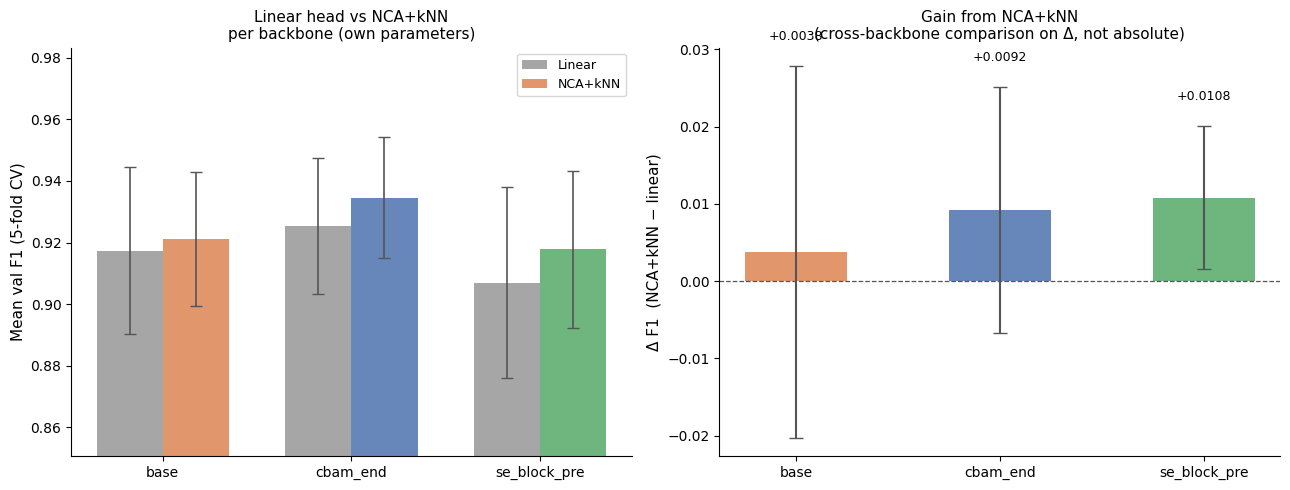

In [15]:
if len(df_ok) == 0:
    print("No completed runs yet — run Section 6 first.")
else:
    colours = {"base": "#DD8452", "cbam_end": "#4C72B0", "se_block_pre": "#55A868"}
    x = np.arange(len(BACKBONES))
    width = 0.35

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # ── Panel 1: absolute F1 comparison ──────────────────────────────────────
    ax = axes[0]
    for i, backbone in enumerate(BACKBONES):
        row = summary[summary["backbone"] == backbone]
        if row.empty:
            continue
        lin_mean = float(row["linear_f1_mean"])
        lin_std  = float(row["linear_f1_std"])
        nca_mean = float(row["nca_knn_f1_mean"])
        nca_std  = float(row["nca_knn_f1_std"])
        td, k    = optimal_params.get(backbone, ("", ""))

        ax.bar(i - width/2, lin_mean, width, color="#888", alpha=0.75,
               label="Linear" if i == 0 else "",
               yerr=lin_std, capsize=4,
               error_kw=dict(elinewidth=1.2, ecolor="#555"))
        ax.bar(i + width/2, nca_mean, width,
               color=colours.get(backbone, "#4C72B0"), alpha=0.85,
               label="NCA+kNN" if i == 0 else "",
               yerr=nca_std, capsize=4,
               error_kw=dict(elinewidth=1.2, ecolor="#555"))

    ax.set_xticks(x)
    ax.set_xticklabels(BACKBONES, fontsize=10)
    ax.set_ylabel("Mean val F1 (5-fold CV)", fontsize=11)
    ax.set_title("Linear head vs NCA+kNN\nper backbone (own parameters)", fontsize=11)
    ax.legend(fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)

    all_f1 = df_ok[["nca_knn_f1", "linear_f1"]].values.flatten()
    pad = (all_f1.max() - all_f1.min()) * 0.25 or 0.02
    ax.set_ylim(max(0, all_f1.min() - pad), min(1, all_f1.max() + pad))

    # ── Panel 2: Δ gain per backbone ─────────────────────────────────────────
    ax2 = axes[1]
    for i, backbone in enumerate(BACKBONES):
        row = summary[summary["backbone"] == backbone]
        if row.empty:
            continue
        dm = float(row["delta_f1_mean"])
        ds = float(row["delta_f1_std"])
        colour = colours.get(backbone, "#4C72B0") if dm >= 0 else "#E05C2A"

        ax2.bar(i, dm, width=0.5, color=colour, alpha=0.85,
                yerr=ds, capsize=5,
                error_kw=dict(elinewidth=1.5, ecolor="#555"))
        ax2.text(i, dm + (ds + 0.003) * np.sign(dm) if dm != 0 else 0.003,
                 f"{dm:+.4f}", ha="center",
                 va="bottom" if dm >= 0 else "top", fontsize=9)

    ax2.axhline(0, color="#555", linewidth=0.9, linestyle="--")
    ax2.set_xticks(range(len(BACKBONES)))
    ax2.set_xticklabels(BACKBONES, fontsize=10)
    ax2.set_ylabel("Δ F1  (NCA+kNN − linear)", fontsize=11)
    ax2.set_title("Gain from NCA+kNN\n(cross-backbone comparison on Δ, not absolute)",
                  fontsize=11)
    ax2.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    save_fig(fig, "nca_knn_comparison")
    plt.show()

Saved → C:\Users\markm\Workspace\ms-machine-learning-diagnosis\src\notebooks\CNNS\nca-knn-results\plots\nca_knn_fold_scatter.png / .svg


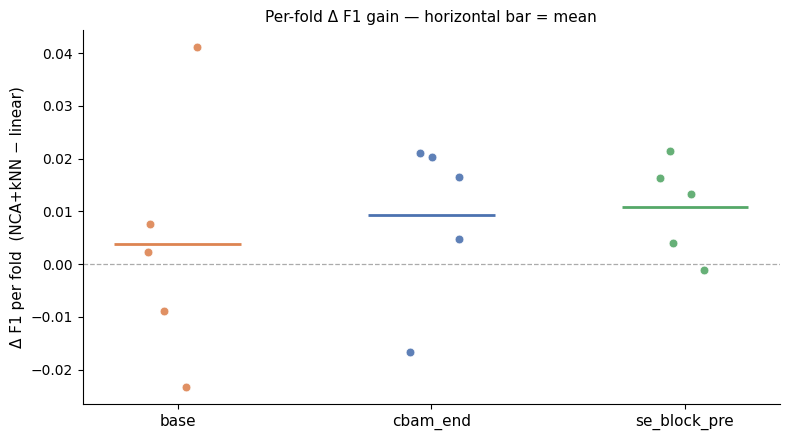

In [16]:
# ── Per-fold scatter: fold-level Δ values ────────────────────────────────────
if len(df_ok) > 0:
    fig, ax = plt.subplots(figsize=(8, 4.5))

    for i, backbone in enumerate(BACKBONES):
        rows = df_ok[df_ok["backbone"] == backbone].sort_values("fold")
        if rows.empty:
            continue
        colour = colours.get(backbone, "#4C72B0")
        jitter = np.random.default_rng(i).uniform(-0.12, 0.12, size=len(rows))
        ax.scatter(i + jitter, rows["delta_f1"].values,
                   color=colour, edgecolors="white", linewidths=0.6,
                   s=40, zorder=3, alpha=0.9)
        dm = rows["delta_f1"].mean()
        ax.hlines(dm, i - 0.25, i + 0.25, colors=colour, linewidth=2.0)

    ax.axhline(0, color="#888", linewidth=0.9, linestyle="--", alpha=0.7)
    ax.set_xticks(range(len(BACKBONES)))
    ax.set_xticklabels(BACKBONES, fontsize=11)
    ax.set_ylabel("Δ F1 per fold  (NCA+kNN − linear)", fontsize=11)
    ax.set_title("Per-fold Δ F1 gain — horizontal bar = mean", fontsize=11)
    ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    save_fig(fig, "nca_knn_fold_scatter")
    plt.show()

## 8 · Final Evaluation on Held-Out Test Set

Run **once only**, after all model selection decisions are made. Uses the backbone with the highest mean NCA+kNN val F1. Trains the full pipeline on all of `X_trainval` and evaluates on `X_test`.

> **Important:** do not use test results to make any further modelling decisions.

In [17]:
if len(df_ok) < total_runs:
    print(f"WARNING: only {len(df_ok)}/{total_runs} folds completed.")
    print("Run Section 6 fully before final evaluation.")
else:
    best_row = summary.sort_values("nca_knn_f1_mean", ascending=False).iloc[0]
    BEST_BACKBONE = best_row["backbone"]
    td_final, k_final = optimal_params[BEST_BACKBONE]
    print(f"Best backbone  : {BEST_BACKBONE}")
    print(f"Parameters     : target_dim={td_final}  k={k_final}")
    print(f"Mean val F1    : {best_row['nca_knn_f1_mean']:.4f} ± {best_row['nca_knn_f1_std']:.4f}")

Best backbone  : cbam_end
Parameters     : target_dim=256  k=5
Mean val F1    : 0.9346 ± 0.0196


In [18]:
if len(df_ok) >= total_runs:
    print(f"\nTraining final NCA+kNN on all X_trainval ({len(X_trainval)} samples)...")

    full_loader = data.get_test_loader(X_trainval, y_trainval, test_transform, BATCH_SIZE)
    test_loader = data.get_test_loader(X_test,     y_test,     test_transform, BATCH_SIZE)

    final_model = models.get_model(architecture=BEST_BACKBONE, head=WINNING_HEAD)
    final_model = utils.load_weights(
        final_model, fold_weights_path(BEST_BACKBONE, 0), device=device
    )

    X_tr_f, y_tr_f = trainer.get_features(final_model, full_loader, device=device)
    X_te_f, y_te_f = trainer.get_features(final_model, test_loader,  device=device)

    scaler_fin = StandardScaler()
    X_tr_sc = scaler_fin.fit_transform(X_tr_f)
    X_te_sc = scaler_fin.transform(X_te_f)

    X_tr_nca, X_te_nca = trainer.get_nca_features(
        X_tr_sc, y_tr_f, X_te_sc,
        TARGET_DIM=td_final, SEED=SEED
    )

    knn_fin  = trainer.get_and_train_knn(X_tr_nca, y_tr_f, NUM_NEIGHBOURS=k_final)
    y_te_pred = evaluator.predict_knn(knn_fin, X_te_nca)

    # kNN does not produce calibrated probabilities — pass y_probs=None
    print("\n" + "="*50)
    print(f"  FINAL TEST SET RESULTS — {BEST_BACKBONE} + NCA+kNN")
    print("="*50)
    evaluator.evaluate_model(y_true=y_te_f, y_pred=y_te_pred, y_probs=None)


Training final NCA+kNN on all X_trainval (1321 samples)...
get_test_loader()>>> Test loader ready — 1321 samples
get_test_loader()>>> Test loader ready — 331 samples
get_model()>>> architecture='cbam_end'  head='linear'
load_weights()>>> Model loaded successfully and set to evaluation mode.
get_nca_features()>>> Fitting NCA to reduce 512 features to 256...
get_nca_features()>>> Reduced Train Feature Shape: (1321, 256)
get_nca_features()>>> Reduced Test Feature Shape: (331, 256)
get_and_train_knn()>>> Training kNN classifier on NCA selected deep features...
predict_knn()>>> Predicting test set labels using kNN classifier...

  FINAL TEST SET RESULTS — cbam_end + NCA+kNN
Accuracy  : 0.9517
Precision : 0.9672
Recall    : 0.9077
F1        : 0.9365
AUC-ROC   : nan
ECE       : nan  (lower = better calibrated; 0 = perfect)
Confusion Matrix:
 [[197   4]
 [ 12 118]]
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.98      0.96       

## 9 · Next Steps

1. **SRQ4 — ViT-B/16 baseline:** Run the ViT notebook with the identical two-phase protocol. Compare `cbam_end` against ViT-B/16 on accuracy, AUC-ROC, ECE, and FLOPs/latency.
2. **Final dissertation tables:** Collect linear head F1 (arch-eval), NCA+kNN Δ gain (this notebook), and ViT comparison metrics into a unified results table.
3. **Grad-CAM (optional):** Load `cbam_end` fold-0 weights and apply `pytorch-grad-cam` for qualitative evidence that attention aligns with lesion regions.